<a href="https://colab.research.google.com/github/nomanabdullah04/MaChineLearning/blob/MachineLearning/SVC_2_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SVM Kernals indepth Intuition and Practical Explanation**

In [ ]:
#Import basic liberies
import numpy as np
import matplotlib.pyplot as plt
x=np.linspace(-5.0,5.0,100)
y=np.sqrt(10**2-x**2)
y=np.hstack([y,-y])
x=np.hstack([x,-x])

In [ ]:
x1=np.linspace(-5.0,5.0,100)
y1=np.sqrt(5**2-x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1])

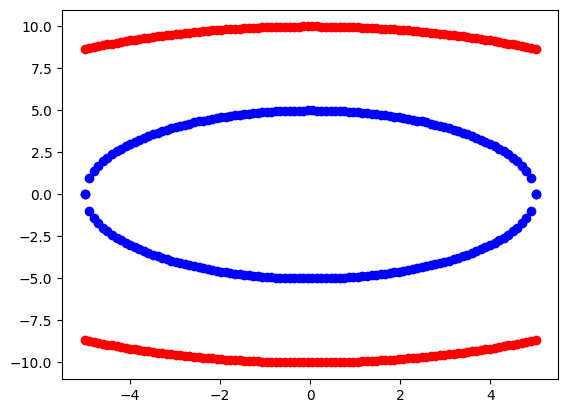

In [ ]:
plt.scatter(x,y,color='red')
plt.scatter(x1,y1,color='blue')
plt.show()

In [ ]:
import pandas as pd
df1=pd.DataFrame(np.vstack([y,x]).T,columns=['x1','x2'])
df1['y']=0
df2=pd.DataFrame(np.vstack([y1,x1]).T,columns=['x1','x2'])
df2['y']=1
df=pd.concat([df1,df2],axis=0)
df.head()

,x1,x2,y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [ ]:
#Define independent and Dependent feature
x=df.iloc[:,:2]
y=df.y

In [ ]:
y

,y
0,0
1,0
2,0
3,0
4,0
...,...
195,1
196,1
197,1
198,1


In [ ]:
#Split the dataset into train and test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [ ]:
y_train

,y
136,1
64,0
55,0
106,0
100,1
...,...
123,1
192,0
117,0
47,0


# **Apply Polynomial Kernal**

In [ ]:
#We need to find compolenet for the polynomial kernal
#x1,x2,x1_squre,x2_square,x1*x2
df['x1_square']=df['x1']**2
df['x2_square']=df['x2']**2
df['x1_x2']=df['x1']*df['x2']
df.head()

,x1,x2,y,x1_square,x2_square,x1_x2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [ ]:
#Define indeplendent and dependent feature
x=df[['x1','x2','x1_square','x2_square','x1_x2']]
y=df.y

In [ ]:
x

,x1,x2,x1_square,x2_square,x1_x2
0,8.660254,-5.00000,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,78.877155,21.122845,-40.818009
...,...,...,...,...,...
195,-1.969049,-4.59596,3.877155,21.122845,9.049671
196,-1.714198,-4.69697,2.938476,22.061524,8.051537
197,-1.406908,-4.79798,1.979390,23.020610,6.750316
198,-0.999949,-4.89899,0.999898,24.000102,4.898740


In [ ]:
y

,y
0,0
1,0
2,0
3,0
4,0
...,...
195,1
196,1
197,1
198,1


In [ ]:
#Again split the data into train and test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)

In [ ]:
x_train

,x1,x2,x1_square,x2_square,x1_x2
50,4.999745,0.050505,24.997449,0.002551,0.252512
63,9.906589,1.363636,98.140496,1.859504,13.508984
112,-3.263736,3.787879,10.651974,14.348026,-12.362637
159,-9.953852,-0.959596,99.079176,0.920824,9.551676
83,3.680983,3.383838,13.549638,11.450362,12.455852
...,...,...,...,...,...
123,-4.223140,2.676768,17.834915,7.165085,-11.304366
192,-9.031653,-4.292929,81.570758,18.429242,38.772248
117,-9.445795,3.282828,89.223038,10.776962,-31.008922
47,9.996811,-0.252525,99.936231,0.063769,-2.524447


In [ ]:
import plotly.express as px
fig=px.scatter_3d(df,x='x1',y='x2',z='x1_x2',color='y')
fig.show()

In [ ]:
fig=px.scatter_3d(df,x='x1_square',y='x2_square',z='x1_x2',color='y')
fig.show()

In [ ]:
from sklearn.svm import SVC
classifier=SVC(kernel='poly',degree=2)
classifier.fit(x_train,y_train)


SVC(degree=2, kernel='poly')

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
y_pred=classifier.predict(x_test)
accuracy_score(y_test,y_pred)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[55  0]
 [ 0 45]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        55
           1       1.00      1.00      1.00        45

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [ ]:
classifier_liner=SVC(kernel='linear',degree=3)
classifier_liner.fit(x_train,y_train)
y_pred_liner=classifier_liner.predict(x_test)
accuracy_score(y_test,y_pred_liner)
print(confusion_matrix(y_test,y_pred_liner))
print(classification_report(y_test,y_pred_liner))

[[55  0]
 [ 0 45]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        55
           1       1.00      1.00      1.00        45

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



## Sigmoid Kernel

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

classifier_sigmoid=SVC(kernel='sigmoid')
classifier_sigmoid.fit(x_train,y_train)
y_pred_sigmoid=classifier_sigmoid.predict(x_test)
accuracy_score(y_test,y_pred_sigmoid)
print(confusion_matrix(y_test,y_pred_sigmoid))
print(classification_report(y_test,y_pred_sigmoid))

[[55  0]
 [ 0 45]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        55
           1       1.00      1.00      1.00        45

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



## RBF Kernel

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

classifier_rbf=SVC(kernel='rbf')
classifier_rbf.fit(x_train,y_train)
y_pred_rbf=classifier_rbf.predict(x_test)
accuracy_score(y_test,y_pred_rbf)
print(confusion_matrix(y_test,y_pred_rbf))
print(classification_report(y_test,y_pred_rbf))

[[55  0]
 [ 0 45]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        55
           1       1.00      1.00      1.00        45

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

